https://www.kaggle.com/datasets/zoya77/dynamic-traffic-signal-sensor-fusion-dataset



In [ ]:

import pandas as pd


df = pd.read_csv('iot_traffic_signal_dataset.csv')


df.head()

,Timestamp,IR_Presence_L1,IR_Presence_L2,IR_Presence_L3,IR_Presence_L4,Vehicle_Count,Average_Speed_kmph,Car_Count,Bike_Count,Bus_Count,Truck_Count,Van_Count,Ambulance_Count,Fire_Truck_Count,Police_Car_Count,Vehicle_Density_Percent,Signal_Duration_Class
0,08:00:00,0,1,0,0,104,42.4,74,10,4,3,7,1,0,1,52.0,Emergency
1,08:00:09,1,1,1,1,36,46.8,1,20,0,9,5,0,1,0,18.0,Emergency
2,08:00:18,0,0,0,1,46,47.3,18,11,3,8,2,0,0,0,23.0,Low
3,08:00:27,0,0,1,1,95,38.9,59,13,1,9,8,1,0,1,47.5,Emergency
4,08:00:37,1,0,1,0,17,44.1,1,5,1,3,5,0,0,1,8.5,Emergency


PREGUNTAS A ESTUDIAR 

1. "¿De qué manera la proporción de diferentes clasificaciones de vehículos altera los niveles de congestión en los momentos de mayor ocupación en la intersección?"

2. "¿Cómo reacciona el sistema dinámico de semáforos ante esta alta densidad vehicular y qué impacto real tiene en la velocidad del tránsito?"

In [ ]:

df.info()

print("\n--- NOMBRES EXACTOS DE LAS COLUMNAS ---")

print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 4637 entries, 0 to 4636
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                4637 non-null   str    
 1   IR_Presence_L1           4637 non-null   int64  
 2   IR_Presence_L2           4637 non-null   int64  
 3   IR_Presence_L3           4637 non-null   int64  
 4   IR_Presence_L4           4637 non-null   int64  
 5   Vehicle_Count            4637 non-null   int64  
 6   Average_Speed_kmph       4637 non-null   float64
 7   Car_Count                4637 non-null   int64  
 8   Bike_Count               4637 non-null   int64  
 9   Bus_Count                4637 non-null   int64  
 10  Truck_Count              4637 non-null   int64  
 11  Van_Count                4637 non-null   int64  
 12  Ambulance_Count          4637 non-null   int64  
 13  Fire_Truck_Count         4637 non-null   int64  
 14  Police_Car_Count         4637 non-n

In [7]:
# 1. EL FILTRO (Equivalente al WHERE en SQL)
# Filtramos los momentos donde la densidad vehicular supera el 70%
momentos_criticos = df[df['Vehicle_Density_Percent'] > 70]

# 2. SELECCIÓN DE VARIABLES
# Creamos una lista solo con las columnas que cuentan los tipos de vehículos pesados y livianos
columnas_vehiculos = ['Car_Count', 'Bike_Count', 'Bus_Count', 'Truck_Count', 'Van_Count']

# 3. CÁLCULO DE COMPOSICIÓN
# Calculamos el promedio de cada tipo de vehículo por minuto durante esos momentos críticos
composicion_critica = momentos_criticos[columnas_vehiculos].mean().round(2)

# Ordenamos los resultados de mayor a menor presencia
composicion_critica = composicion_critica.sort_values(ascending=False)

print("Composición promedio del tránsito (vehículos por minuto) en cuellos de botella:")
print(composicion_critica)
print("-" * 50)

# ---------------------------------------------------------
# BONUS: APLICANDO GROUP BY REAL
# Tu dataset tiene una columna categórica genial: 'Signal_Duration_Class' (El estado del semáforo)
# Vamos a usar tu lógica de SQL para ver cómo la velocidad cambia según el semáforo.

agrupacion_semaforo = df.groupby('Signal_Duration_Class')[['Vehicle_Density_Percent', 'Average_Speed_kmph']].mean().round(2)

print("\nAnálisis de Densidad y Velocidad agrupado por Duración del Semáforo:")
print(agrupacion_semaforo)

Composición promedio del tránsito (vehículos por minuto) en cuellos de botella:
Car_Count      83.04
Bike_Count     46.43
Van_Count       6.13
Truck_Count     5.13
Bus_Count       2.26
dtype: float64
--------------------------------------------------

Análisis de Densidad y Velocidad agrupado por Duración del Semáforo:
                       Vehicle_Density_Percent  Average_Speed_kmph
Signal_Duration_Class                                             
Emergency                                34.21               40.01
High                                     80.50               44.90
Low                                      29.14               40.08
Medium                                   56.68               41.91


C:\Users\Giovanni\AppData\Local\Temp\ipykernel_3776\4217775413.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


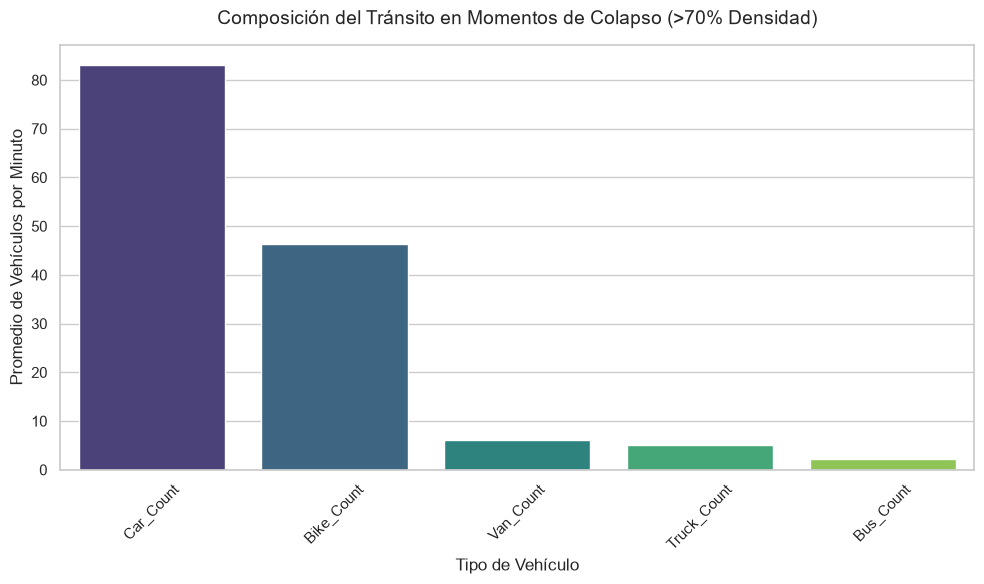

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos los datos nuevamente
df = pd.read_csv('iot_traffic_signal_dataset.csv')

# 2. Hacemos el cálculo (El filtro y la agrupación)
momentos_criticos = df[df['Vehicle_Density_Percent'] > 70]
columnas_vehiculos = ['Car_Count', 'Bike_Count', 'Bus_Count', 'Truck_Count', 'Van_Count']
composicion_critica = momentos_criticos[columnas_vehiculos].mean().round(2).sort_values(ascending=False)

# 3. Dibujamos el GRÁFICO DE COMPOSICIÓN VEHICULAR
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(
    x=composicion_critica.index, 
    y=composicion_critica.values, 
    palette="viridis"
)

plt.title('Composición del Tránsito en Momentos de Colapso (>70% Densidad)', fontsize=14, pad=15)
plt.xlabel('Tipo de Vehículo', fontsize=12)
plt.ylabel('Promedio de Vehículos por Minuto', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

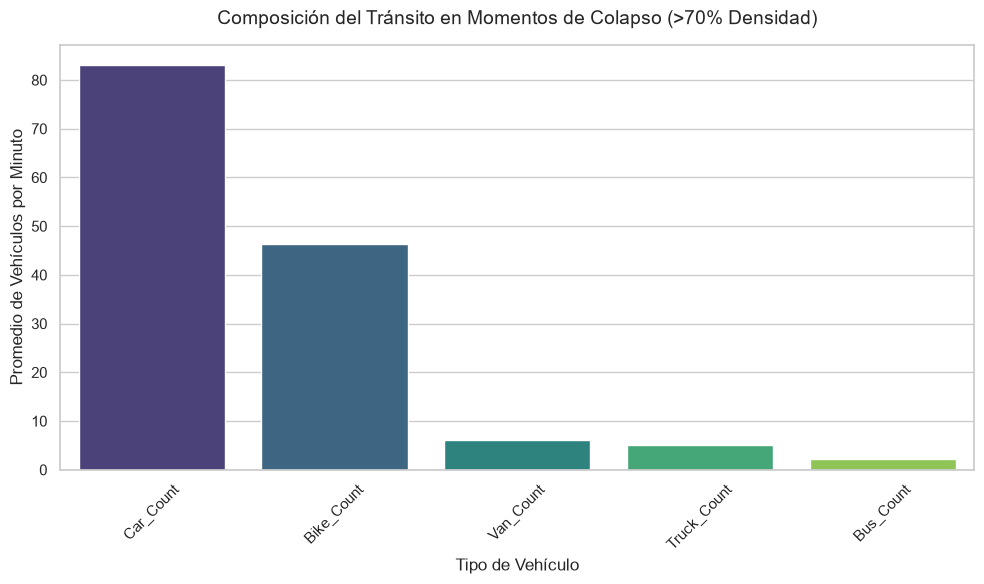

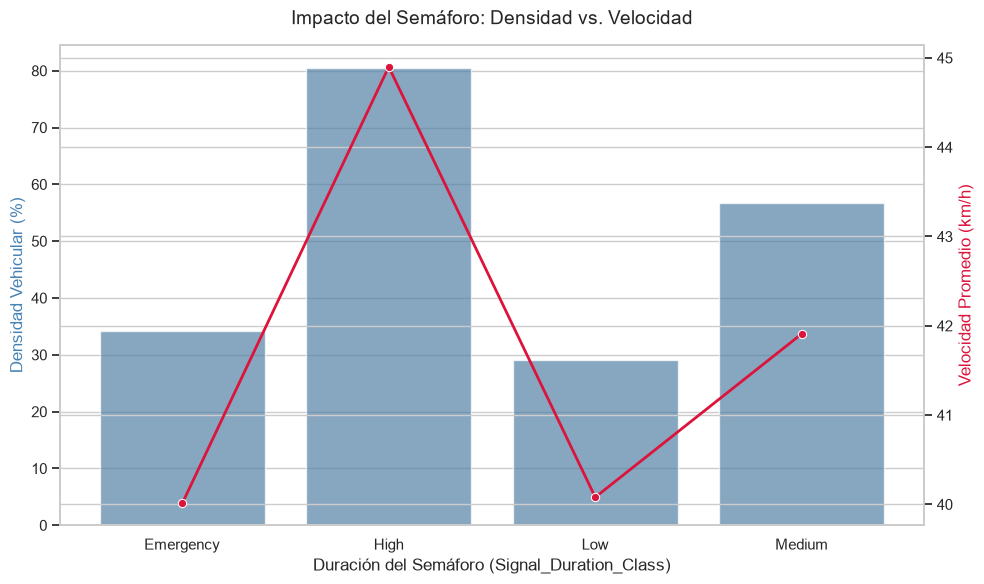

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARACIÓN DE DATOS ---
df = pd.read_csv('iot_traffic_signal_dataset.csv')

# Datos para el Gráfico 1 (Composición)
momentos_criticos = df[df['Vehicle_Density_Percent'] > 70]
columnas_vehiculos = ['Car_Count', 'Bike_Count', 'Bus_Count', 'Truck_Count', 'Van_Count']
composicion_critica = momentos_criticos[columnas_vehiculos].mean().round(2).sort_values(ascending=False)

# Datos para el Gráfico 2 (Semáforos)
agrupacion_semaforo = df.groupby('Signal_Duration_Class')[['Vehicle_Density_Percent', 'Average_Speed_kmph']].mean().round(2)

# Configuración visual general
sns.set_theme(style="whitegrid")

# --- 2. GRÁFICO DE COMPOSICIÓN VEHICULAR ---
plt.figure(figsize=(10, 6))
sns.barplot(
    x=composicion_critica.index, 
    y=composicion_critica.values, 
    hue=composicion_critica.index, # Solución a la advertencia
    palette="viridis",
    legend=False                   # Solución a la advertencia
)

plt.title('Composición del Tránsito en Momentos de Colapso (>70% Densidad)', fontsize=14, pad=15)
plt.xlabel('Tipo de Vehículo', fontsize=12)
plt.ylabel('Promedio de Vehículos por Minuto', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 3. GRÁFICO DE SEMÁFOROS (Doble eje) ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje principal (Izquierda) - Densidad Vehicular
sns.barplot(
    data=agrupacion_semaforo, 
    x=agrupacion_semaforo.index, 
    y='Vehicle_Density_Percent', 
    color='steelblue', 
    alpha=0.7, 
    ax=ax1
)
ax1.set_ylabel('Densidad Vehicular (%)', fontsize=12, color='steelblue')
ax1.set_xlabel('Duración del Semáforo (Signal_Duration_Class)', fontsize=12)

# Eje secundario (Derecha) - Velocidad Promedio
ax2 = ax1.twinx() 
sns.lineplot(
    data=agrupacion_semaforo, 
    x=agrupacion_semaforo.index, 
    y='Average_Speed_kmph', 
    color='crimson', 
    marker='o', 
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('Velocidad Promedio (km/h)', fontsize=12, color='crimson')

plt.title('Impacto del Semáforo: Densidad vs. Velocidad', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### 📌 Conclusión: Dinámica de los Cuellos de Botella
Al filtrar los momentos críticos de la intersección (densidad > 70%), el análisis revela que la saturación está impulsada principalmente por el volumen masivo de vehículos particulares y de menor porte. 
* Se registra un promedio de **~83 automóviles y ~46 motocicletas por minuto**.
* El tránsito pesado (camiones y colectivos) representa una fracción mínima (< 10 vehículos/minuto combinados). 
**Insight Analítico:** El colapso del flujo vehicular no responde a bloqueos generados por vehículos de gran tamaño, sino a la superación de la capacidad espacial de la avenida por parte del tránsito ligero.

### 📌 Conclusión: Respuesta del Sistema de Señalización
Al analizar el comportamiento conjunto de la densidad y la velocidad en función de la duración del semáforo, observamos el efecto directo de la señalización dinámica:
* En el estado **"High"** (mayor duración de luz verde), la intersección alcanza su pico máximo de densidad (80.5%).
* Paradójicamente, en este mismo estado se registra **la velocidad promedio más alta (44.9 km/h)**.
**Insight Analítico:** El sistema detecta correctamente los picos de congestión y prolonga el tiempo de paso. Esto permite que el gran volumen acumulado logre acelerar de manera constante, logrando "desagotar" el embotellamiento de manera eficiente.